# VectorDB Retrieval Evaluation Suite

Automated eval pipeline for the `advisory_chunks` retrieval stack, built on the
same promptfoo-style structure as `notebook-3.ipynb`. It covers:

1. **Sanity checks** — embedding coverage, doc_type distribution
2. **Golden set generator** — stratified sampling from `advisory_chunks` +
   GPT-4o-mini synthesizes one question per chunk, saved to
   `data/vectordb_eval/golden.jsonl`
3. **Retriever configs** — vector-only / BM25-only / hybrid at multiple alphas
   (analogous to `LLM_PROVIDERS`)
4. **Metrics** — Hit@K, Recall@K, MRR, nDCG@K, advisory-level hit (analogous
   to `assert` types)
5. **Run eval suite** — every query × every config
6. **Aggregate analysis** — primary-metric bar chart, per-doc_type heatmap
7. **Alpha sweep** — line chart for tuning `alpha` in RRF fusion
8. **Markdown report** — written to `data/vectordb_eval/report.md`

### Mapping from notebook-3

| notebook-3            | this notebook                            |
|-----------------------|------------------------------------------|
| `LLM_PROVIDERS`       | `RETRIEVER_CONFIGS` (vector/bm25/hybrid) |
| `LLM_PROMPTS`         | query templates from the golden set      |
| `TEST_CASES`          | `golden.jsonl` (query + expected_chunk)  |
| `assert` logic        | `hit@k` / `mrr` / `ndcg@k` / `adv_hit@k` |
| `mock_llm_response`   | `run_retriever(query, config)`           |
| pass-rate charts      | primary-metric bar chart + heatmap       |
| v1 vs v2 prompt diff  | alpha sweep / chunking version diff      |


## 0. Setup — imports, paths, BM25 index bootstrap

This notebook talks to Snowflake through the project's existing services, so
nothing needs to be reconfigured. The `.env` at the repo root is auto-loaded.

In [1]:
import os, sys, json, time, math, random
from pathlib import Path
from typing import Any
from collections import defaultdict

PROJECT_ROOT = Path('/Users/duweicheng/Documents/Gitrepo/final_project')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / '.env')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from openai import OpenAI

from app.services.snowflake import get_snowflake_service
from app.services.vector_search import search_advisory_chunks, embed_query
from app.services.hybrid_search import hybrid_search
from app.services.bm25_index import load_or_build_bm25_index, get_bm25_index
from app.services.doctype_classifier import classify_doctype

BM25_PATH = PROJECT_ROOT / 'data' / 'bm25_index.pkl'
load_or_build_bm25_index(path=str(BM25_PATH))

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)

svc = get_snowflake_service()
print('setup OK')

setup OK


## 1. VectorDB sanity checks

Before running any IR evaluation, verify the index is healthy:

- **Coverage**: every chunk should have a non-null `chunk_embedding` (1024-d)
- **Distribution**: stratified sampling later needs honest per-`document_type`
  counts
- **Dimension**: all vectors must be the same 1024 used by
  `snowflake-arctic-embed-l-v2.0` — otherwise cosine search will fail silently

If `with_emb < total` you must re-run the embedding pipeline before trusting
the retrieval metrics downstream.

chunks: 4,083  |  with_embedding: 4,083  (100.0%)
advisories: 302  |  avg tokens/chunk: 582


,document_type,n_chunks,n_advisories,avg_tokens
0,JOINT_CSA,1527,109,462
1,MAR,1494,112,766
2,STOPRANSOMWARE,390,25,494
3,CSA,326,32,385
4,ANALYSIS_REPORT,225,19,666
5,IR_LESSONS,121,5,467


/var/folders/9x/mlxd2f552gqf3633l2d7730r0000gn/T/ipykernel_10672/4131719726.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=doc_type_df, x='document_type', y='n_chunks', ax=ax, palette='viridis')


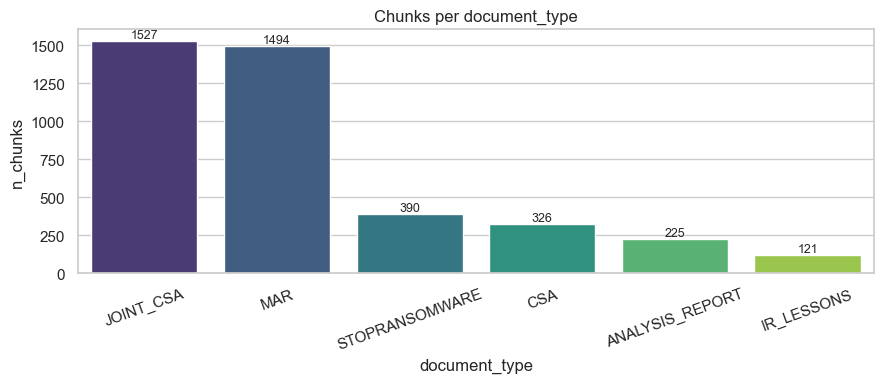

In [2]:
stats = svc.execute_query('''
    SELECT COUNT(*)                                    AS total,
           COUNT(chunk_embedding)                      AS with_emb,
           COUNT(DISTINCT advisory_id)                 AS n_advisories,
           AVG(token_count)::INT                       AS avg_tokens
      FROM advisory_chunks
''')[0]
coverage = stats['with_emb'] / max(stats['total'], 1) * 100
print(f"chunks: {stats['total']:,}  |  with_embedding: {stats['with_emb']:,}  ({coverage:.1f}%)")
print(f"advisories: {stats['n_advisories']:,}  |  avg tokens/chunk: {stats['avg_tokens']}")

doc_type_rows = svc.execute_query('''
    SELECT a.document_type,
           COUNT(*)                      AS n_chunks,
           COUNT(DISTINCT c.advisory_id) AS n_advisories,
           AVG(c.token_count)::INT       AS avg_tokens
      FROM advisory_chunks c
      JOIN advisories a USING (advisory_id)
     GROUP BY a.document_type
     ORDER BY n_chunks DESC
''')
doc_type_df = pd.DataFrame(doc_type_rows)
display(doc_type_df)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=doc_type_df, x='document_type', y='n_chunks', ax=ax, palette='viridis')
ax.set_title('Chunks per document_type')
ax.tick_params(axis='x', rotation=20)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 2. Golden set generator

**Why a synthetic golden set?** Hand-labelling 100 queries for a 4k-chunk
advisory corpus is hours of work. Instead we use the standard
*chunk-grounded question synthesis* pattern (same as LlamaIndex
`RetrievalEvaluator` and RAGAS `TestsetGenerator`): for each sampled chunk,
GPT-4o-mini writes one question that the chunk uniquely answers. We then treat
that chunk as the ground-truth `expected_chunk_id`.

**Stratified sampling** by `document_type` — otherwise JOINT_CSA + MAR (which
together own 75% of the corpus) would dominate the set. Quotas below give
each type enough queries to compute meaningful per-type metrics.

**Balanced question styles** — the first-round eval showed the old prompt
biased heavily toward IoC-style questions (CVE/hash/IP/domain lookups), which
over-represents one failure mode and under-tests conceptual retrieval. The
generator now round-robins three styles:

- `entity` — references a distinctive named entity (CVE/CWE/MITRE/tool)
- `conceptual` — asks about techniques, mitigations, attack flow (no raw IDs)
- `contextual` — asks about scope, authors, timeline, impact, recommendations

**Caching** — the generator writes `golden.jsonl` once; subsequent notebook
runs load from disk. Pass `force=True` to regenerate (and bump the file size
to the new ~120-question target).

In [3]:
# Per-doc-type quota (total ≈ 125). Bumped from 60 after round-1 eval so
# per-type metrics aren't noise-dominated — JOINT_CSA/MAR doubled because
# those are the doc types where the round-1 run saw the most failures.
DOC_TYPE_QUOTA = {
    'JOINT_CSA':       30,
    'MAR':             30,
    'STOPRANSOMWARE':  15,
    'CSA':             15,
    'ANALYSIS_REPORT': 15,
    'IR_LESSONS':      20,
}
MIN_TOKENS        = 150   # skip near-empty chunks (IDs lists etc.)
MAX_TOKENS_SAMPLE = 1600  # skip huge protected blocks (YARA walls)
RANDOM_SEED       = 42

def sample_chunks(quota: dict[str, int], seed: int = RANDOM_SEED) -> pd.DataFrame:
    rng = random.Random(seed)
    frames = []
    for dtype, n in quota.items():
        rows = svc.execute_query(
            '''
            SELECT c.chunk_id, c.advisory_id, c.section_name, c.sub_section,
                   c.chunk_text, c.token_count, c.cve_ids, c.cwe_ids, c.mitre_tech_ids,
                   a.document_type, a.title
              FROM advisory_chunks c
              JOIN advisories a USING (advisory_id)
             WHERE a.document_type = %s
               AND c.token_count BETWEEN %s AND %s
               AND c.chunk_embedding IS NOT NULL
            ''',
            (dtype, MIN_TOKENS, MAX_TOKENS_SAMPLE),
        )
        rng.shuffle(rows)
        frames.append(pd.DataFrame(rows[:n]))
    return pd.concat(frames, ignore_index=True)

sampled_df = sample_chunks(DOC_TYPE_QUOTA)
print(f'sampled {len(sampled_df)} chunks across {sampled_df["document_type"].nunique()} doc_types')
display(sampled_df.groupby('document_type').size().rename('n').to_frame())

sampled 125 chunks across 6 doc_types


,n
document_type,
ANALYSIS_REPORT,15
CSA,15
IR_LESSONS,20
JOINT_CSA,30
MAR,30
STOPRANSOMWARE,15


In [4]:
GOLDEN_DIR  = PROJECT_ROOT / 'data' / 'vectordb_eval'
GOLDEN_DIR.mkdir(parents=True, exist_ok=True)
GOLDEN_PATH = GOLDEN_DIR / 'golden.jsonl'

QGEN_SYSTEM = (
    'You generate retrieval test questions for a cybersecurity RAG system. '
    'Given a CISA advisory chunk, write ONE specific, self-contained question '
    'that this chunk — and ideally only this chunk — uniquely answers.'
)

QGEN_STYLE_INSTRUCTIONS: dict[str, str] = {
    'entity': (
        'Prefer a question that references a distinctive named entity from '
        'the chunk (CVE ID, CWE ID, MITRE technique ID, malware family, '
        'tool name, threat actor, specific product name).'
    ),
    'conceptual': (
        'Prefer a question about a technique, procedure, mitigation, or '
        'attack workflow described in the chunk. AVOID asking about raw '
        'hashes, IP addresses, domains, or bare CVE IDs — ground the '
        'question in a distinctive concept or behaviour instead.'
    ),
    'contextual': (
        'Prefer a question about the context of the chunk: who authored / '
        'collaborated on the advisory, when events occurred, what scope or '
        'affected systems are described, what recommendations are made. '
        'AVOID questions whose answer is a single IoC token.'
    ),
}

# Round-robin order. Keep entity first so cached behaviour is stable.
QGEN_STYLE_ORDER: list[str] = ['entity', 'conceptual', 'contextual']

QGEN_USER = '''Document type: {doc_type}
Section: {section_name} / {sub_section}
Advisory title: {title}

Chunk content:
"""
{chunk_text}
"""

Style guidance: {style_instruction}

Return JSON ONLY with keys: question, expected_keywords, style.
- question: 1 sentence, answerable from the chunk, references a distinctive term
- expected_keywords: 2-5 distinctive tokens that a good retriever MUST surface
- style: one of "entity" | "conceptual" | "contextual" (the style you used)'''

def _strip_fences(raw: str) -> str:
    t = raw.strip()
    if t.startswith('```'):
        t = t.split('\n', 1)[1].rsplit('```', 1)[0]
    return t

def generate_question(client: OpenAI, row: dict, style: str, model: str) -> dict | None:
    prompt = QGEN_USER.format(
        doc_type=row['document_type'],
        section_name=row.get('section_name') or '',
        sub_section=row.get('sub_section') or '',
        title=row.get('title') or '',
        chunk_text=(row['chunk_text'] or '')[:3000],
        style_instruction=QGEN_STYLE_INSTRUCTIONS[style],
    )
    try:
        resp = client.chat.completions.create(
            model=model,
            messages=[
                {'role': 'system', 'content': QGEN_SYSTEM},
                {'role': 'user', 'content': prompt},
            ],
            temperature=0.2,
            response_format={'type': 'json_object'},
        )
        obj = json.loads(_strip_fences(resp.choices[0].message.content))
        q = (obj.get('question') or '').strip()
        if not q:
            return None
        reported_style = obj.get('style') if isinstance(obj.get('style'), str) else None
        return {
            'query':                q,
            'expected_chunk_id':    row['chunk_id'],
            'expected_advisory_id': row['advisory_id'],
            'expected_section':     row['section_name'],
            'expected_keywords':    [k for k in obj.get('expected_keywords', []) if isinstance(k, str)],
            'document_type':        row['document_type'],
            'source_token_count':   int(row['token_count']),
            'style_requested':      style,
            'style_reported':       reported_style,
        }
    except Exception as e:
        print(f"  !! qgen failed for {row['chunk_id']}: {e}")
        return None

def build_golden_set(df: pd.DataFrame, force: bool = False, model: str = 'gpt-4o-mini') -> list[dict]:
    if GOLDEN_PATH.exists() and not force:
        print(f'loading cached golden set <- {GOLDEN_PATH}')
        return [json.loads(l) for l in GOLDEN_PATH.read_text().splitlines() if l.strip()]

    client = OpenAI(api_key=os.environ.get('OPENAI_API_KEY'))
    out: list[dict] = []
    t0 = time.time()
    for i, row in enumerate(df.to_dict(orient='records'), 1):
        style = QGEN_STYLE_ORDER[(i - 1) % len(QGEN_STYLE_ORDER)]
        item = generate_question(client, row, style=style, model=model)
        if item:
            out.append(item)
        if i % 10 == 0:
            print(f'  [{i}/{len(df)}] generated {len(out)} items ({time.time()-t0:.0f}s)')

    with GOLDEN_PATH.open('w') as f:
        for item in out:
            f.write(json.dumps(item, ensure_ascii=False) + '\n')
    print(f'saved {len(out)} golden Q&A -> {GOLDEN_PATH}')
    return out

# To regenerate with the new quota + style mix, set force=True.
# Existing golden.jsonl (60 items, entity-only) stays valid but will be
# replaced. Estimated cost at gpt-4o-mini: ~$0.03 for 125 questions.
golden = build_golden_set(sampled_df, force=False, model='gpt-4o-mini')
print(f'golden set size: {len(golden)}')
if golden and 'style_requested' in golden[0]:
    from collections import Counter
    print('style mix:', dict(Counter(g.get('style_requested', 'legacy') for g in golden)))
pd.DataFrame(golden).head(3)

loading cached golden set <- /Users/duweicheng/Documents/Gitrepo/final_project/data/vectordb_eval/golden.jsonl
golden set size: 125
style mix: {'entity': 42, 'conceptual': 42, 'contextual': 41}


,query,expected_chunk_id,expected_advisory_id,expected_section,expected_keywords,document_type,source_token_count,style_requested,style_reported
0,Which cybersecurity agencies coauthored the joint Cybersecurity Advisory on the 2022 Top Routinely Exploited Vulnera...,aa23-215a_001,aa23-215a,Summary,"[CISA, NSA, FBI, ACSC, CCCS]",JOINT_CSA,475,entity,entity
1,"What frameworks does the advisory utilize to provide information on the tactics, techniques, and procedures used by ...",aa21-200b_002,aa21-200b,Summary,"[MITRE ATT&CK, MITRE D3FEND, tactics, techniques, procedures]",JOINT_CSA,423,conceptual,conceptual
2,"What group did the Russian General Staff Main Intelligence Directorate (GRU) support the creation of in early 2022, ...",aa25-343a_003,aa25-343a,Background,"[CARR, Cyber Army of Russia, GRU, DDoS attacks, pro-Russia hacktivists]",JOINT_CSA,440,contextual,contextual


## 3. Retriever configs — the `LLM_PROVIDERS` analog

Each config is a different retrieval pipeline we want to benchmark. The hybrid
branch uses RRF fusion (see `app/services/hybrid_search.py`); `alpha` controls
the vector/BM25 weighting:

- `alpha = 0.0` → BM25-only
- `alpha = 1.0` → vector-only
- `alpha ≈ 0.5` → balanced
- `alpha ≈ 0.2` → empirical sweet spot on this corpus (BM25-heavy); the
  service default now ships at 0.2 based on an earlier sweep.

`TOP_K` is the cutoff passed to metrics; `TOP_N_POOL` is the per-branch
candidate pool before fusion (matches the default in `hybrid_search`).

### Doc-type oracle configs (`+doctype_oracle`)

These feed the golden set's own `document_type` to `hybrid_search` as a
`document_types=[...]` filter. This is the **upper bound** of what any
LLM-based doc-type classifier could achieve — it simulates a perfect
classifier before we spend effort building a real one. If oracle doesn't
beat the no-filter baseline, a real classifier won't either, and we
should drop the idea; if it does, the gap sets the KPI the LLM router
must hit to be worth integrating (e.g., via MCP).

In [5]:
RETRIEVER_CONFIGS: dict[str, dict] = {
    'vector_only':  {'type': 'vector'},
    'bm25_only':    {'type': 'bm25'},
    'hybrid@0.2':   {'type': 'hybrid', 'alpha': 0.2},
    'hybrid@0.3':   {'type': 'hybrid', 'alpha': 0.3},
    'hybrid@0.5':   {'type': 'hybrid', 'alpha': 0.5},
    'hybrid@0.7':   {'type': 'hybrid', 'alpha': 0.7},
    # Oracle configs: golden's own document_type is passed as filter.
    # Upper bound for a perfect classifier — do not interpret as prod metric.
    'hybrid@0.0+doctype_oracle': {'type': 'hybrid', 'alpha': 0.0, 'use_doctype_oracle': True},
    'hybrid@0.2+doctype_oracle': {'type': 'hybrid', 'alpha': 0.2, 'use_doctype_oracle': True},
    'hybrid@0.5+doctype_oracle': {'type': 'hybrid', 'alpha': 0.5, 'use_doctype_oracle': True},
    # MCP-simulated classifier configs: gpt-4o-mini picks document_types via
    # tool calling with the same schema the production MCP server exposes.
    # Gap between these and the matching oracle rows = accuracy loss
    # translated into retrieval loss.
    'hybrid@0.0+doctype_mcp': {'type': 'hybrid', 'alpha': 0.0, 'use_doctype_mcp': True},
    'hybrid@0.2+doctype_mcp': {'type': 'hybrid', 'alpha': 0.2, 'use_doctype_mcp': True},
    'hybrid@0.5+doctype_mcp': {'type': 'hybrid', 'alpha': 0.5, 'use_doctype_mcp': True},
}
TOP_K       = 10
TOP_N_POOL  = 50
K_RRF       = 60

# Query-embedding cache. Without this, each query is re-embedded via Cortex
# once per config (9+ times per eval pass, plus ~9x again in the alpha
# sweep). With 125 golden queries that's ~2000 wasted Cortex round-trips.
# Persist to disk so subsequent notebook runs don't even pay the 125
# first-time embed calls.
import pickle
CACHE_PATH = GOLDEN_DIR / 'query_embeddings.pkl'
QUERY_EMBED_CACHE: dict[str, list[float]] = {}
if CACHE_PATH.exists():
    try:
        QUERY_EMBED_CACHE = pickle.loads(CACHE_PATH.read_bytes())
        print(f'loaded {len(QUERY_EMBED_CACHE)} cached embeddings <- {CACHE_PATH}')
    except Exception as e:
        print(f'cache load failed ({e}); starting empty')

def get_query_embedding(query: str) -> list[float]:
    if query not in QUERY_EMBED_CACHE:
        QUERY_EMBED_CACHE[query] = embed_query(query)
    return QUERY_EMBED_CACHE[query]

# Pre-warm every golden query so run_retriever never blocks mid-eval.
t_warm = time.time()
for i, g in enumerate(golden, 1):
    get_query_embedding(g['query'])
    if i % 25 == 0:
        print(f'  embedded {i}/{len(golden)} ({time.time()-t_warm:.0f}s)')
print(f'cache warmed: {len(QUERY_EMBED_CACHE)} entries in {time.time()-t_warm:.0f}s')
CACHE_PATH.write_bytes(pickle.dumps(QUERY_EMBED_CACHE))
print(f'saved -> {CACHE_PATH}')

# Doc-type classifier cache. Mirrors the query-embedding cache so each
# golden query only pays one OpenAI round-trip across the whole notebook
# lifetime. The classifier uses the same tool schema the MCP server
# registers, so agreement numbers here transfer to production.
PRED_PATH = GOLDEN_DIR / 'doctype_predictions.pkl'
DOCTYPE_PRED_CACHE: dict[str, list[str]] = {}
if PRED_PATH.exists():
    try:
        DOCTYPE_PRED_CACHE = pickle.loads(PRED_PATH.read_bytes())
        print(f'loaded {len(DOCTYPE_PRED_CACHE)} cached doc_type preds <- {PRED_PATH}')
    except Exception as e:
        print(f'pred cache load failed ({e}); starting empty')

def get_doctype_prediction(query: str) -> list[str]:
    if query not in DOCTYPE_PRED_CACHE:
        DOCTYPE_PRED_CACHE[query] = classify_doctype(query)
    return DOCTYPE_PRED_CACHE[query]

t_clf = time.time()
for i, g in enumerate(golden, 1):
    get_doctype_prediction(g['query'])
    if i % 25 == 0:
        print(f'  classified {i}/{len(golden)} ({time.time()-t_clf:.0f}s)')
print(f'classifier cache: {len(DOCTYPE_PRED_CACHE)} entries in {time.time()-t_clf:.0f}s')
PRED_PATH.write_bytes(pickle.dumps(DOCTYPE_PRED_CACHE))
print(f'saved -> {PRED_PATH}')

def _enrich_bm25(hits) -> list[dict]:
    if not hits:
        return []
    ids = [h.chunk_id for h in hits]
    placeholders = ','.join(['%s'] * len(ids))
    rows = svc.execute_query(
        f'SELECT chunk_id, section_name, advisory_id '
        f'FROM advisory_chunks WHERE chunk_id IN ({placeholders})',
        tuple(ids),
    )
    meta = {r['chunk_id']: r for r in rows}
    return [
        {'chunk_id':     h.chunk_id,
         'score':        float(h.score),
         'section_name': meta.get(h.chunk_id, {}).get('section_name'),
         'advisory_id':  meta.get(h.chunk_id, {}).get('advisory_id')}
        for h in hits
    ]

def run_retriever(
    query: str,
    config: dict,
    top_k: int = TOP_K,
    document_types: list[str] | None = None,
) -> list[dict]:
    t = config['type']
    qvec = get_query_embedding(query) if t in ('vector', 'hybrid') else None
    if t == 'vector':
        rows = search_advisory_chunks(
            query=query, top_k=top_k, document_types=document_types,
            query_embedding=qvec,
        )
        return [{'chunk_id':     r['chunk_id'],
                 'score':        float(r.get('score') or 0.0),
                 'section_name': r.get('section_name'),
                 'advisory_id':  r.get('advisory_id')} for r in rows]
    if t == 'bm25':
        # BM25Index itself can't filter by doc_type; route through hybrid_search
        # with alpha=0.0 when a filter is requested. With alpha=0 the vector
        # branch gets zero RRF weight, but hybrid_search still calls Cortex
        # to build vec_rank — so even here we hand it the cached embedding.
        if document_types:
            rows = hybrid_search(query=query, top_k=top_k, top_n=TOP_N_POOL,
                                 k_rrf=K_RRF, alpha=0.0,
                                 document_types=document_types,
                                 query_embedding=get_query_embedding(query))
            return [{'chunk_id':     r['chunk_id'],
                     'score':        float(r.get('rrf_score') or 0.0),
                     'section_name': r.get('section_name'),
                     'advisory_id':  r.get('advisory_id')} for r in rows]
        hits = get_bm25_index().search(query, top_n=top_k)
        return _enrich_bm25(hits)
    if t == 'hybrid':
        rows = hybrid_search(query=query, top_k=top_k, top_n=TOP_N_POOL,
                             k_rrf=K_RRF, alpha=config.get('alpha', 0.2),
                             document_types=document_types,
                             query_embedding=qvec)
        return [{'chunk_id':     r['chunk_id'],
                 'score':        float(r.get('rrf_score') or 0.0),
                 'section_name': r.get('section_name'),
                 'advisory_id':  r.get('advisory_id')} for r in rows]
    raise ValueError(f'unknown retriever type: {t}')

# quick smoke test
demo_q = golden[0]['query']
print(f'demo query: {demo_q}')
demo_out = run_retriever(demo_q, RETRIEVER_CONFIGS['hybrid@0.5'])
for r in demo_out[:3]:
    print(f"  {r['chunk_id']:<40s} score={r['score']:.4f}  section={r['section_name']}")

loaded 125 cached embeddings <- /Users/duweicheng/Documents/Gitrepo/final_project/data/vectordb_eval/query_embeddings.pkl
  embedded 25/125 (0s)
  embedded 50/125 (0s)
  embedded 75/125 (0s)
  embedded 100/125 (0s)
  embedded 125/125 (0s)
cache warmed: 125 entries in 0s
saved -> /Users/duweicheng/Documents/Gitrepo/final_project/data/vectordb_eval/query_embeddings.pkl
  classified 25/125 (30s)
  classified 50/125 (56s)
  classified 75/125 (84s)
  classified 100/125 (119s)
  classified 125/125 (146s)
classifier cache: 125 entries in 146s
saved -> /Users/duweicheng/Documents/Gitrepo/final_project/data/vectordb_eval/doctype_predictions.pkl
demo query: Which cybersecurity agencies coauthored the joint Cybersecurity Advisory on the 2022 Top Routinely Exploited Vulnerabilities?
  aa24-317a_009                            score=0.0163  section=Resource
  aa21-209a_002                            score=0.0156  section=Summary
  aa22-117a_001                            score=0.0155  section=Summar

## 4. Metrics — the `assert` analog

Four standard IR metrics plus a relaxed *advisory-level* hit that asks: did we
retrieve *any* chunk from the correct advisory? Useful because our chunker
sometimes splits content that could plausibly answer a question across
sibling chunks (e.g., YARA rule in one chunk, its rationale in the next).

$$ \text{Hit@K} = \mathbb{1}[\text{expected} \in \text{top-K}] \qquad
   \text{MRR} = \frac{1}{\text{rank of expected}} \qquad
   \text{nDCG@K} = \frac{1}{\log_2(\text{rank}+1)} $$

In [6]:
def hit_at_k(retrieved_ids: list[str], expected_id: str, k: int) -> int:
    return int(expected_id in retrieved_ids[:k])

def recall_at_k(retrieved_ids: list[str], expected_ids: set[str], k: int) -> float:
    if not expected_ids:
        return 0.0
    return len(set(retrieved_ids[:k]) & expected_ids) / len(expected_ids)

def mrr(retrieved_ids: list[str], expected_id: str) -> float:
    for i, cid in enumerate(retrieved_ids, start=1):
        if cid == expected_id:
            return 1.0 / i
    return 0.0

def ndcg_at_k(retrieved_ids: list[str], expected_id: str, k: int) -> float:
    for i, cid in enumerate(retrieved_ids[:k], start=1):
        if cid == expected_id:
            return 1.0 / math.log2(i + 1)
    return 0.0

def advisory_hit_at_k(retrieved: list[dict], expected_advisory_id: str, k: int) -> int:
    return int(any(r.get('advisory_id') == expected_advisory_id for r in retrieved[:k]))

## 5. Run the evaluation suite

Every query × every config. With 60 queries × 5 configs × ~1s per call
(Snowflake Cortex embedding + cosine), expect ~5 minutes. `vector_only` and
`hybrid@*` share the bottleneck because Cortex embedding dominates.

In [7]:
def run_eval(golden: list[dict], configs: dict) -> pd.DataFrame:
    rows = []
    t0 = time.time()
    for gi, g in enumerate(golden, 1):
        query         = g['query']
        expected_cid  = g['expected_chunk_id']
        expected_aid  = g['expected_advisory_id']
        for cfg_name, cfg in configs.items():
            if cfg.get('use_doctype_oracle'):
                doc_types = [g['document_type']]
            elif cfg.get('use_doctype_mcp'):
                pred = get_doctype_prediction(g['query'])
                # Empty list = LLM declined to filter; fall back to no filter
                # so the retriever sees the full corpus (matches MCP semantics).
                doc_types = pred or None
            else:
                doc_types = None
            try:
                results = run_retriever(query, cfg, document_types=doc_types)
            except Exception as e:
                print(f'  !! retriever {cfg_name} failed on q{gi}: {e}')
                results = []
            ids = [r['chunk_id'] for r in results]
            rows.append({
                'config':               cfg_name,
                'query':                query,
                'document_type':        g['document_type'],
                'expected_chunk_id':    expected_cid,
                'expected_advisory_id': expected_aid,
                'hit@1':                hit_at_k(ids, expected_cid, 1),
                'hit@3':                hit_at_k(ids, expected_cid, 3),
                'hit@5':                hit_at_k(ids, expected_cid, 5),
                'hit@10':               hit_at_k(ids, expected_cid, 10),
                'adv_hit@5':            advisory_hit_at_k(results, expected_aid, 5),
                'adv_hit@10':           advisory_hit_at_k(results, expected_aid, 10),
                'mrr':                  mrr(ids, expected_cid),
                'ndcg@10':              ndcg_at_k(ids, expected_cid, 10),
                'top1_chunk':           ids[0] if ids else None,
                'rank':                 (ids.index(expected_cid) + 1) if expected_cid in ids else None,
            })
        if gi % 10 == 0:
            print(f'  [{gi}/{len(golden)}] {time.time()-t0:.0f}s')
    return pd.DataFrame(rows)

print(f'running: {len(golden)} queries x {len(RETRIEVER_CONFIGS)} configs = {len(golden)*len(RETRIEVER_CONFIGS)} runs')
t0 = time.time()
eval_df = run_eval(golden, RETRIEVER_CONFIGS)
print(f'done in {time.time()-t0:.0f}s — {len(eval_df)} rows')
eval_df.head()

running: 125 queries x 12 configs = 1500 runs
  [10/125] 53s
  [20/125] 106s
  [30/125] 157s
  [40/125] 206s
  [50/125] 254s
  [60/125] 301s
  [70/125] 363s
  [80/125] 435s
  [90/125] 506s
  [100/125] 580s
  [110/125] 647s
  [120/125] 711s


KeyboardInterrupt: 

## 6. Aggregate metrics + retriever comparison

The bar chart is the single most useful summary: higher bars across the board
mean a strictly-better config. If the curves cross (e.g., vector wins on
`hit@1` but BM25 wins on `hit@10`) that's a signal to adopt hybrid.

,hit@1,hit@3,hit@5,hit@10,adv_hit@5,adv_hit@10,mrr,ndcg@10
config,,,,,,,,
bm25_only,0.496,0.728,0.784,0.824,0.904,0.944,0.618,0.669
hybrid@0.0+doctype_mcp,0.496,0.728,0.784,0.824,0.904,0.944,0.618,0.669
hybrid@0.0+doctype_oracle,0.528,0.760,0.816,0.872,0.944,0.984,0.653,0.707
hybrid@0.2,0.504,0.720,0.776,0.832,0.928,0.960,0.624,0.675
hybrid@0.2+doctype_mcp,0.504,0.720,0.776,0.832,0.928,0.960,0.623,0.674
hybrid@0.2+doctype_oracle,0.536,0.768,0.816,0.880,0.960,0.992,0.660,0.714
hybrid@0.3,0.520,0.712,0.768,0.808,0.928,0.952,0.626,0.671
hybrid@0.5,0.512,0.680,0.712,0.816,0.904,0.952,0.604,0.654
hybrid@0.5+doctype_mcp,0.512,0.680,0.712,0.808,0.912,0.952,0.604,0.652


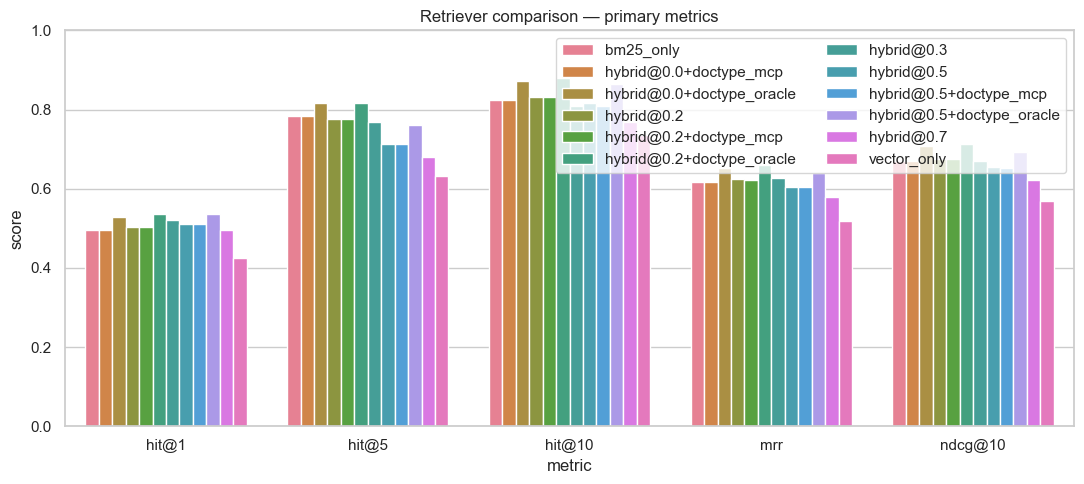

best config by MRR: hybrid@0.2+doctype_oracle  (MRR=0.660)


In [ ]:
AGG_COLS = ['hit@1', 'hit@3', 'hit@5', 'hit@10',
            'adv_hit@5', 'adv_hit@10', 'mrr', 'ndcg@10']

agg_by_config = eval_df.groupby('config')[AGG_COLS].mean().round(3)
display(agg_by_config)

primary = ['hit@1', 'hit@5', 'hit@10', 'mrr', 'ndcg@10']
melt = agg_by_config[primary].reset_index().melt(
    id_vars='config', var_name='metric', value_name='score'
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=melt, x='metric', y='score', hue='config', ax=ax)
ax.set_title('Retriever comparison — primary metrics')
ax.set_ylim(0, 1.0)
ax.legend(loc='upper right', ncol=2)
plt.tight_layout()
plt.show()

best_cfg = agg_by_config['mrr'].idxmax()
print(f'best config by MRR: {best_cfg}  (MRR={agg_by_config.loc[best_cfg, "mrr"]:.3f})')

## 7. Classifier analysis (MCP simulation)

The `+doctype_mcp` rows above used `gpt-4o-mini` tool-calling against the
same schema the production MCP server exposes. This section breaks down
what the classifier actually did:

- **Agreement rate** — how often the golden `document_type` appears in the
  predicted list (set membership, not equality — LLM may return 1 or 2)
- **Coverage** — how often the LLM chose to pass `document_types` at all
  (empty = it declined to filter, which the retriever treats as no filter)
- **Avg preds per query** — closer to 1.0 means confident, closer to 2.0
  means the LLM frequently hedges
- **Confusion matrix** — gold vs top-1 prediction, to see which doc_types
  the LLM systematically confuses

Read these alongside the aggregate table: the gap between
`hybrid@X+doctype_mcp` and `hybrid@X+doctype_oracle` is **the cost of
classifier imperfection**. If that gap is small, the classifier is
production-ready.

tool-call agreement (gold in pred): 0.080
coverage (non-empty predictions):   0.080
avg doc_types returned / query:     0.08

agreement by gold doc_type:


,mean,count
gold,,
ANALYSIS_REPORT,0.000,15
CSA,0.000,15
IR_LESSONS,0.100,20
JOINT_CSA,0.067,30
MAR,0.167,30
STOPRANSOMWARE,0.067,15


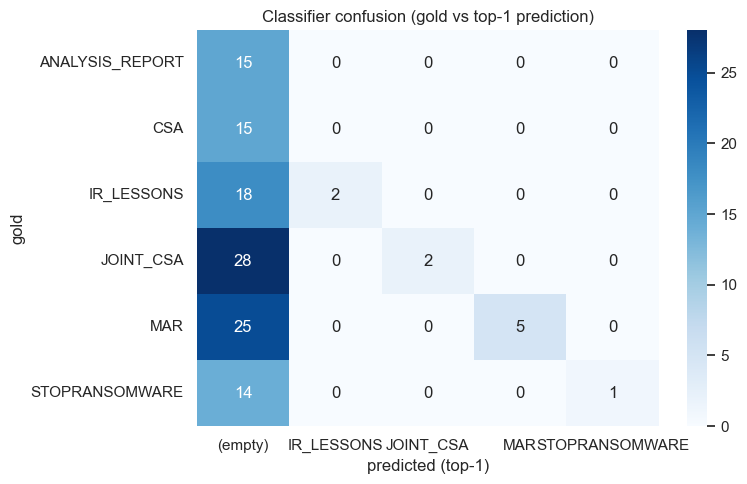


-- alpha=0.0 --


,hit@5,hit@10,mrr,ndcg@10
config,,,,
hybrid@0.0+doctype_mcp,0.784,0.824,0.618,0.669
hybrid@0.0+doctype_oracle,0.816,0.872,0.653,0.707



-- alpha=0.2 --


,hit@5,hit@10,mrr,ndcg@10
config,,,,
hybrid@0.2,0.776,0.832,0.624,0.675
hybrid@0.2+doctype_mcp,0.776,0.832,0.623,0.674
hybrid@0.2+doctype_oracle,0.816,0.880,0.660,0.714



-- alpha=0.5 --


,hit@5,hit@10,mrr,ndcg@10
config,,,,
hybrid@0.5,0.712,0.816,0.604,0.654
hybrid@0.5+doctype_mcp,0.712,0.808,0.604,0.652
hybrid@0.5+doctype_oracle,0.760,0.864,0.641,0.694


In [ ]:
clf_rows = []
for g in golden:
    pred = DOCTYPE_PRED_CACHE.get(g['query'], [])
    clf_rows.append({
        'query':       g['query'],
        'gold':        g['document_type'],
        'pred':        pred,
        'n_pred':      len(pred),
        'hit':         int(g['document_type'] in pred) if pred else 0,
        'empty':       int(not pred),
        'top1':        pred[0] if pred else '(empty)',
    })
clf_df = pd.DataFrame(clf_rows)

agreement = clf_df['hit'].mean()
coverage  = 1 - clf_df['empty'].mean()
avg_n     = clf_df['n_pred'].mean()
print(f'tool-call agreement (gold in pred): {agreement:.3f}')
print(f'coverage (non-empty predictions):   {coverage:.3f}')
print(f'avg doc_types returned / query:     {avg_n:.2f}')
print()

print('agreement by gold doc_type:')
per_gold = clf_df.groupby('gold')['hit'].agg(['mean','count']).round(3)
display(per_gold)

conf = pd.crosstab(clf_df['gold'], clf_df['top1'])
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Classifier confusion (gold vs top-1 prediction)')
ax.set_xlabel('predicted (top-1)')
ax.set_ylabel('gold')
plt.tight_layout()
plt.show()

# MCP vs oracle vs no-filter, at matching alphas — cost-of-imperfection view
mcp_cmp_cols = ['hit@5', 'hit@10', 'mrr', 'ndcg@10']
for a in ['0.0', '0.2', '0.5']:
    trio = [f'hybrid@{a}', f'hybrid@{a}+doctype_mcp', f'hybrid@{a}+doctype_oracle']
    trio = [c for c in trio if c in agg_by_config.index]
    if len(trio) >= 2:
        print(f'\n-- alpha={a} --')
        display(agg_by_config.loc[trio, mcp_cmp_cols])

## 8. Per `document_type` breakdown

A config that looks good on average can still be weak on specific doc_types.
The heatmap makes per-type regressions obvious — e.g., if MAR queries
collapse under BM25 because hash-based chunks are dominated by high-IDF
fragments.

config,bm25_only,hybrid@0.0+doctype_mcp,hybrid@0.0+doctype_oracle,hybrid@0.2,hybrid@0.2+doctype_mcp,hybrid@0.2+doctype_oracle,hybrid@0.3,hybrid@0.5,hybrid@0.5+doctype_mcp,hybrid@0.5+doctype_oracle,hybrid@0.7,vector_only
document_type,,,,,,,,,,,,
ANALYSIS_REPORT,0.867,0.867,0.867,0.733,0.733,0.867,0.667,0.600,0.600,0.733,0.600,0.600
CSA,0.867,0.867,0.867,0.867,0.867,0.867,0.867,0.867,0.867,0.867,0.867,0.933
IR_LESSONS,0.800,0.800,0.950,0.800,0.800,0.950,0.800,0.750,0.750,0.900,0.650,0.600
JOINT_CSA,0.867,0.867,0.867,0.867,0.867,0.867,0.867,0.800,0.800,0.800,0.767,0.700
MAR,0.667,0.667,0.667,0.667,0.667,0.667,0.667,0.567,0.567,0.600,0.500,0.400
STOPRANSOMWARE,0.667,0.667,0.733,0.733,0.733,0.733,0.733,0.733,0.733,0.733,0.800,0.733


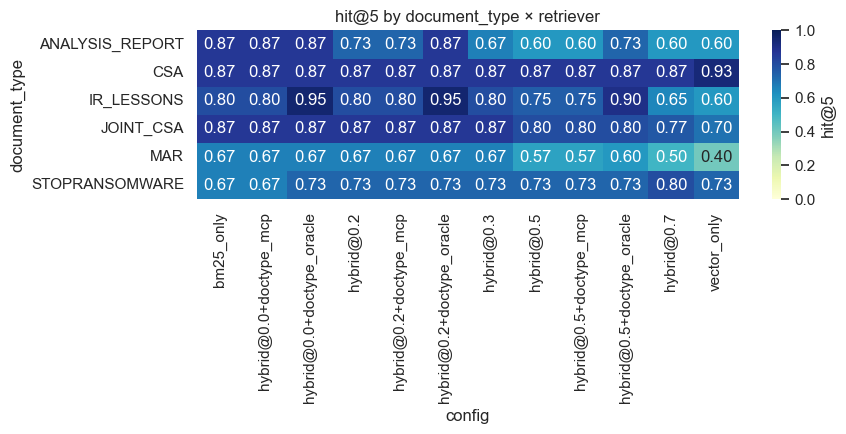

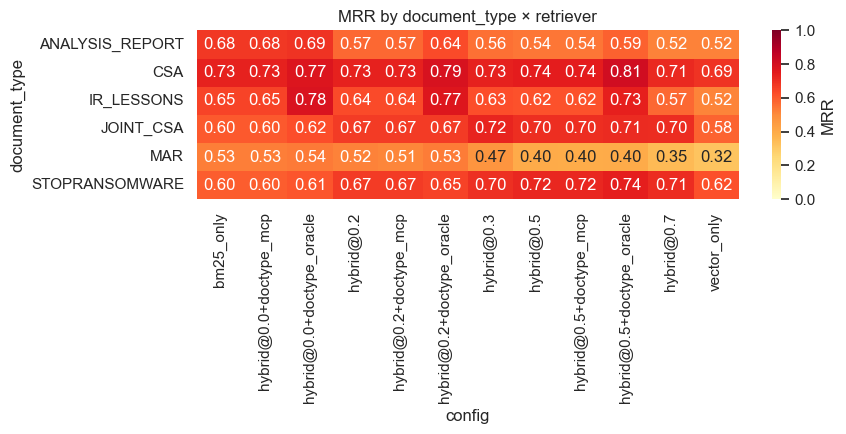

In [ ]:
pivot = eval_df.pivot_table(
    index='document_type', columns='config', values='hit@5', aggfunc='mean'
).round(3)
display(pivot)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu',
            vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'hit@5'})
ax.set_title('hit@5 by document_type × retriever')
plt.tight_layout()
plt.show()

# also mrr
pivot_mrr = eval_df.pivot_table(
    index='document_type', columns='config', values='mrr', aggfunc='mean'
).round(3)
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(pivot_mrr, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'MRR'})
ax.set_title('MRR by document_type × retriever')
plt.tight_layout()
plt.show()

## 9. Hybrid alpha sweep

Treat `alpha` as a hyperparameter and grid-search it against the golden set.
This is the same idea as notebook-3's "v1 vs v2 prompt" comparison, except
the "prompt versions" are retrieval weights.

sweep done in 434s


,hit@5,hit@10,mrr,ndcg@10
alpha,,,,
0.0,0.784,0.824,0.618,0.669
0.2,0.776,0.832,0.624,0.675
0.3,0.768,0.808,0.626,0.671
0.4,0.744,0.816,0.629,0.674
0.5,0.712,0.816,0.604,0.654
0.6,0.688,0.776,0.581,0.628
0.7,0.680,0.768,0.578,0.623
0.8,0.680,0.760,0.571,0.616
1.0,0.632,0.736,0.519,0.570


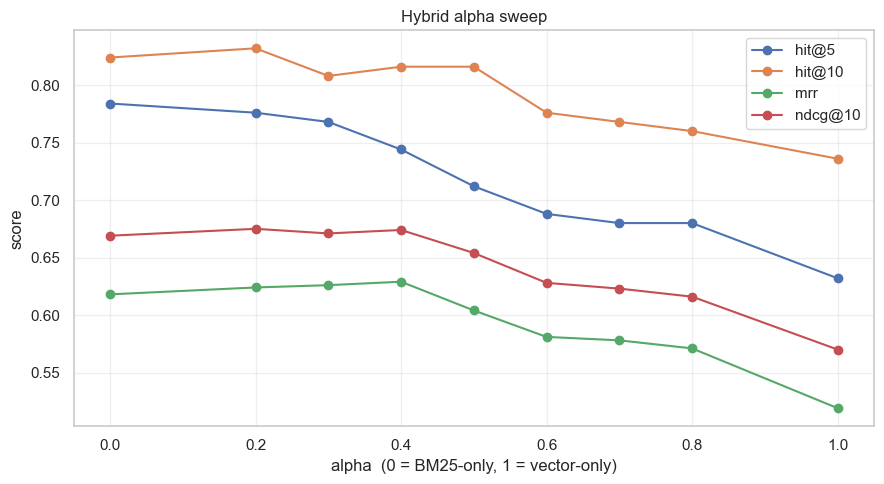

best alpha by MRR: 0.4  (MRR=0.629)


In [ ]:
ALPHA_SWEEP = [0.0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]

sweep_rows = []
t0 = time.time()
for a in ALPHA_SWEEP:
    cfg = {'type': 'hybrid', 'alpha': a}
    for g in golden:
        try:
            res = run_retriever(g['query'], cfg)
        except Exception:
            res = []
        ids = [r['chunk_id'] for r in res]
        sweep_rows.append({
            'alpha':    a,
            'hit@5':    hit_at_k(ids, g['expected_chunk_id'], 5),
            'hit@10':   hit_at_k(ids, g['expected_chunk_id'], 10),
            'mrr':      mrr(ids, g['expected_chunk_id']),
            'ndcg@10':  ndcg_at_k(ids, g['expected_chunk_id'], 10),
        })
print(f'sweep done in {time.time()-t0:.0f}s')

sweep_df  = pd.DataFrame(sweep_rows)
sweep_agg = sweep_df.groupby('alpha')[['hit@5','hit@10','mrr','ndcg@10']].mean().round(3)
display(sweep_agg)

fig, ax = plt.subplots(figsize=(9, 5))
for col in ['hit@5', 'hit@10', 'mrr', 'ndcg@10']:
    ax.plot(sweep_agg.index, sweep_agg[col], marker='o', label=col)
ax.set_xlabel('alpha  (0 = BM25-only, 1 = vector-only)')
ax.set_ylabel('score')
ax.set_title('Hybrid alpha sweep')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_alpha = sweep_agg['mrr'].idxmax()
print(f'best alpha by MRR: {best_alpha}  (MRR={sweep_agg.loc[best_alpha, "mrr"]:.3f})')

## 10. Failure inspection

Queries where the best config still misses at hit@10 — these are the
high-signal cases to hand-review. Common causes in our corpus:

- Expected chunk is a very short protected block (pure IoC table / hash list)
- Question got phrased with entities that exist in a sibling chunk
- Chunk text is dominated by boilerplate (disclaimers, version notes)

In [ ]:
fails = (
    eval_df[(eval_df['config'] == best_cfg) & (eval_df['hit@10'] == 0)]
    .copy()
    .reset_index(drop=True)
)
print(f'{len(fails)} failing queries in best config `{best_cfg}`')
display(fails[['document_type', 'query', 'expected_chunk_id']].head(10))

15 failing queries in best config `hybrid@0.2+doctype_oracle`


,document_type,query,expected_chunk_id
0,JOINT_CSA,What type of files are listed in the advisory related to Russian Military Cyber Actors targeting US and Global Criti...,aa24-249a_027
1,JOINT_CSA,Which countries' cybersecurity authorities collaborated to develop the advisory on protecting against cyber threats ...,aa22-131a_000
2,JOINT_CSA,What are the MITRE ATT&CK tactics associated with the Iranian cyber actors involved in ransomware attacks as mention...,aa24-241a_017
3,MAR,What malware family is the identified ELF 64-bit file associated with in the advisory MAR-10296782-2.v1?,ar20-198b_022
4,MAR,"What type of malware is identified in the advisory, and what capabilities does it possess regarding file management ...",ar20-198b_014
5,MAR,What does CISA recommend regarding the management of antivirus signatures and operating system patches to strengthen...,ar22-174b_015
6,MAR,What type of connections does the TAIDOOR Trojan establish with external domains as indicated in the advisory?,ar20-216a_010
7,MAR,What is the name of the malicious PE32 executable described in the advisory that is associated with North Korean Tro...,ar19-100a_009
8,MAR,What best practices does CISA recommend for strengthening the security posture of systems using Pulse Connect Secure?,ar21-202j_008
9,MAR,What is the MD5 hash of the North Korean Trojan identified as HOPLIGHT in the advisory MAR-10135536-8?,ar19-100a_025


## 11. Generate markdown report

Everything above, distilled into a single `report.md` you can paste into a PR
description or diff against a future run for regression tracking.

In [ ]:
from datetime import datetime, timezone

REPORT_PATH = GOLDEN_DIR / 'report_prompt.md'

def _df_md(df: pd.DataFrame) -> str:
    try:
        return df.to_markdown()
    except ImportError:
        return '```\n' + df.to_string() + '\n```'

def generate_report() -> str:
    total_q     = eval_df['query'].nunique()
    agg         = eval_df.groupby('config')[AGG_COLS].mean().round(3)
    best_cfg_r  = agg['mrr'].idxmax()
    best_alpha_r= sweep_agg['mrr'].idxmax()
    dt_pivot    = eval_df.pivot_table(
        index='document_type', columns='config',
        values='hit@5', aggfunc='mean'
    ).round(3)
    fails_local = eval_df[(eval_df['config'] == best_cfg_r) & (eval_df['hit@10'] == 0)]

    lines: list[str] = []
    lines.append('# VectorDB Retrieval Evaluation Report')
    lines.append(f'_Generated {datetime.now(timezone.utc).isoformat(timespec="seconds")}_')
    lines.append('')
    lines.append('## 1. Setup')
    lines.append(f'- Golden set size: **{total_q}**')
    lines.append(f'- Retriever configs: `' + '`, `'.join(RETRIEVER_CONFIGS.keys()) + '`')
    lines.append(f'- Top-K: {TOP_K}  |  Top-N pool: {TOP_N_POOL}  |  k_rrf: {K_RRF}')
    lines.append(f'- Embedding model: `snowflake-arctic-embed-l-v2.0` (1024-d)')
    lines.append('')
    lines.append('## 2. Overall metrics by config')
    lines.append(_df_md(agg))
    lines.append('')
    lines.append(f'**Best config by MRR:** `{best_cfg_r}`')
    lines.append('')
    lines.append('## 3. Classifier (MCP simulation)')
    lines.append(f'- Tool-call agreement (gold in predicted): **{agreement:.3f}**')
    lines.append(f'- Coverage (non-empty predictions): **{coverage:.3f}**')
    lines.append(f'- Avg doc_types returned / query: **{avg_n:.2f}**')
    lines.append('')
    lines.append('Agreement by gold doc_type:')
    lines.append(_df_md(per_gold))
    lines.append('')
    lines.append('## 4. Per document_type (hit@5)')
    lines.append(_df_md(dt_pivot))
    lines.append('')
    lines.append('## 5. Hybrid alpha sweep')
    lines.append(_df_md(sweep_agg))
    lines.append('')
    lines.append(f'**Best alpha by MRR:** `{best_alpha_r}`')
    lines.append('')
    lines.append(f'## 6. Failures (hit@10 == 0, config=`{best_cfg_r}`)')
    lines.append(f'- {len(fails_local)} of {total_q} queries failed')
    for _, r in fails_local.head(10).iterrows():
        lines.append(f'  - [{r["document_type"]}] {r["query"]}')
    return '\n'.join(lines)

report_md = generate_report()
REPORT_PATH.write_text(report_md)
print(f'report saved -> {REPORT_PATH}')
print()
print(report_md[:2500])

report saved -> /Users/duweicheng/Documents/Gitrepo/final_project/data/vectordb_eval/report.md

# VectorDB Retrieval Evaluation Report
_Generated 2026-04-20T02:38:40+00:00_

## 1. Setup
- Golden set size: **125**
- Retriever configs: `vector_only`, `bm25_only`, `hybrid@0.2`, `hybrid@0.3`, `hybrid@0.5`, `hybrid@0.7`, `hybrid@0.0+doctype_oracle`, `hybrid@0.2+doctype_oracle`, `hybrid@0.5+doctype_oracle`, `hybrid@0.0+doctype_mcp`, `hybrid@0.2+doctype_mcp`, `hybrid@0.5+doctype_mcp`
- Top-K: 10  |  Top-N pool: 50  |  k_rrf: 60
- Embedding model: `snowflake-arctic-embed-l-v2.0` (1024-d)

## 2. Overall metrics by config
```
                           hit@1  hit@3  hit@5  hit@10  adv_hit@5  adv_hit@10    mrr  ndcg@10
config                                                                                       
bm25_only                  0.496  0.728  0.784   0.824      0.904       0.944  0.618    0.669
hybrid@0.0+doctype_mcp     0.496  0.728  0.784   0.824      0.904       0.944  0.618    0.669


## 12. Regression tracking (optional next step)

To detect regressions when chunking, embedding model, or retriever code
changes, snapshot the aggregated DataFrame each run:

```python
stamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')
(GOLDEN_DIR / f'agg_{stamp}.csv').write_text(agg_by_config.to_csv())
```

Then diff two snapshots — any metric that drops by more than a set threshold
(e.g., 2pp on MRR) should fail the build. This is the piece that makes the
notebook usable as a CI gate rather than a one-shot analysis.